# 1. 全体的なモデルを用いた反事実的編集結果のeffectiveness評価結果が悪い原因の調査

## 1.1 調査1: そもそも反因果予測器の性能はどのくらいなのか？

### とりあえずmorphomnistの訓練セット・テストセットの画像数枚の各属性値を予測器で予測してみる

In [11]:
### データや反因果予測器に関する諸設定 ###

data_dir = "/home/hashikami/datadrive/morphomnist_all_model"
attribute_size = {"thickness": 1, "intensity": 1, "slant": 1, "width": 1}
config_cls = {
    "anticausal_graph": {
        "thickness": ["intensity", "slant", "width"],
        "intensity": [],
        "slant": [],
        "width": []
    },


    "attribute_size": {
        "thickness": 1,
        "intensity": 1,
        "slant": 1,
        "width": 1
    },

    "dataset": "morphomnist",
    "ckpt_path" : "/home/hashikami/checkpoint/benchmark/morphomnist/anticausal_classifier/",
    "in_shape" : [1, 28, 28] ,
    "patience" : 10,
    "batch_size_train" : 100,
    "batch_size_val" : 100,
    "lr" : 1e-3,
    "max_epochs" : 1000,
    "train_val_split" : 0.8,
    "ema": "True"
}

In [31]:
### morphomnist for classifierの訓練セット・テストセットの準備 ###

from dataset.morphomnist import MorphoMNISTLikeForClassifier
from dataset.transforms import ReturnDictTransform
import torch

transform = ReturnDictTransform(attribute_size)
data = MorphoMNISTLikeForClassifier(attribute_size=attribute_size, split="train", normalize_=True, transform=transform, data_dir=data_dir)

train_set, val_set = torch.utils.data.random_split(data, [config_cls["train_val_split"],
                                                        1-config_cls["train_val_split"]])

train_data_loader = torch.utils.data.DataLoader(train_set, batch_size=config_cls["batch_size_train"], shuffle=True, drop_last=False,)
val_data_loader = torch.utils.data.DataLoader(val_set, batch_size=config_cls["batch_size_val"], shuffle=False)

one_train_batch = {k: v.to("cuda") for k, v in next(iter(train_data_loader)).items()}
one_val_batch = {k: v.to("cuda") for k, v in next(iter(val_data_loader)).items()}

In [14]:
### 反因果予測器の準備 ###

from evaluate.anticausal.classifiers.classifier import Classifier
import os
import torch


predictors = {atr: Classifier(attr=atr, num_outputs=attribute_size[atr], context_dim=len(list(config_cls["anticausal_graph"][atr]))) for atr in attribute_size.keys()}
for key, cls in predictors.items():
    file_name = next((file for file in os.listdir(config_cls["ckpt_path"]) if file.startswith(key)), None)
    cls.load_state_dict(torch.load(config_cls["ckpt_path"] + file_name , map_location=torch.device('cuda'))["state_dict"])
    cls.to('cuda')

In [15]:
### 反因果予測器による予測 ###

from dataset.morphomnist import unnormalize


def evaluate_one_batch(one_batch, predictors):

    targets = {key: value for key , value in one_batch.items() if key!="image"}
    predictions = {
        key: clfs(one_batch['image'], torch.cat([one_batch['intensity'].view(-1, 1), one_batch['slant'].view(-1, 1), one_batch['width'].view(-1, 1)], dim=1))
        if key=='thickness'
        else clfs(one_batch['image']) for key , clfs in predictors.items()
    }
    result = {key: (unnormalize(targets[key], key) - unnormalize(predictions[key], key)).abs().mean().cpu().detach().numpy() for key in targets}
    
    return result


In [ ]:
train_result = evaluate_one_batch(one_train_batch, predictors)
val_result = evaluate_one_batch(one_val_batch, predictors)

train_result = {atr: train_result[atr].item() for atr in train_result}
print(train_result)
val_result = {atr: val_result[atr].item() for atr in val_result}
print(val_result)

{'thickness': 0.06038394942879677, 'intensity': 5.485362529754639, 'slant': 1.5894737243652344, 'width': 0.9783814549446106}
{'thickness': 0.05144417658448219, 'intensity': 8.420780181884766, 'slant': 1.4007070064544678, 'width': 1.089054822921753}


## 1.2 調査2:全体モデルで反事実的編集した結果を反因果予測器で予測した結果とターゲット値の比較

### データセット・config・pipelineの準備

In [1]:
### morphomnistデータセットの準備 ###

import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from dataset.morphomnist import MorphoMNISTLike
from diffusion.utils.utils import resize_images

# Example usage
batch_size = 100
dataset = MorphoMNISTLike(root_dir="/home/hashikami/datadrive/MorphoMNIST",
                            columns=['intensity', 'thickness'], train=False)
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

batch = next(iter(data_loader))
print(type(batch))
print(batch['image'].unsqueeze(1).shape)
print(batch['thickness'].shape)

/home/hashikami/projects/Diff/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/hashikami/projects/Diff/.venv/lib/python3.8/site-packages/torchvision/io/image.py:11: UserWarning: Failed to load image Python extension: /home/hashikami/projects/Diff/.venv/lib/python3.8/site-packages/torchvision/image.so: undefined symbol: _ZNK3c1010TensorImpl36is_contiguous_nondefault_policy_implENS_12MemoryFormatE
  warn(f"Failed to load image Python extension: {e}")
/home/hashikami/projects/Diff/dataset/morphomnist.py:118: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of war

<class 'dict'>
torch.Size([100, 1, 28, 28])
torch.Size([100])


In [61]:
import os

os.chdir("/home/hashikami/projects/Diff")

from pathlib import Path
from pipeline.utils import dict2namespace
import yaml


config_path = Path("config/config_all.yaml")
with open(config_path, "r") as f:
    config_raw = yaml.load(f, Loader=yaml.FullLoader)
config = dict2namespace(config_raw)

In [3]:
%load_ext autoreload
%autoreload 2

from pipeline.causal_pipeline import CausalPipeline

pipeline = CausalPipeline(config)

### 原因究明1:morphomnistに対するcareflはちゃんと学習できているのか？

In [5]:
# careflの訓練

from dataset.morphomnist import load_morphomnist_like
import numpy as np

dataset_dir = "/home/hashikami/datadrive/morphomnist_all_model"
_, _, metrics_df = load_morphomnist_like(dataset_dir)
metrics = metrics_df.to_numpy().astype(np.float32)
B_true = np.load(config.image_data.meta_data.causalgraph_path)
config.carefl.scale_shift_base = True
config.carefl_training.epochs = 30
carefl = pipeline.train_meta_causal_model(metrics, B_true)

Training meta-causal model


100%|██████████| 30/30 [03:39<00:00,  7.30s/it]


In [ ]:
# causal_pipeline.pyを修正してリロードした場合

pipeline.carefl = carefl

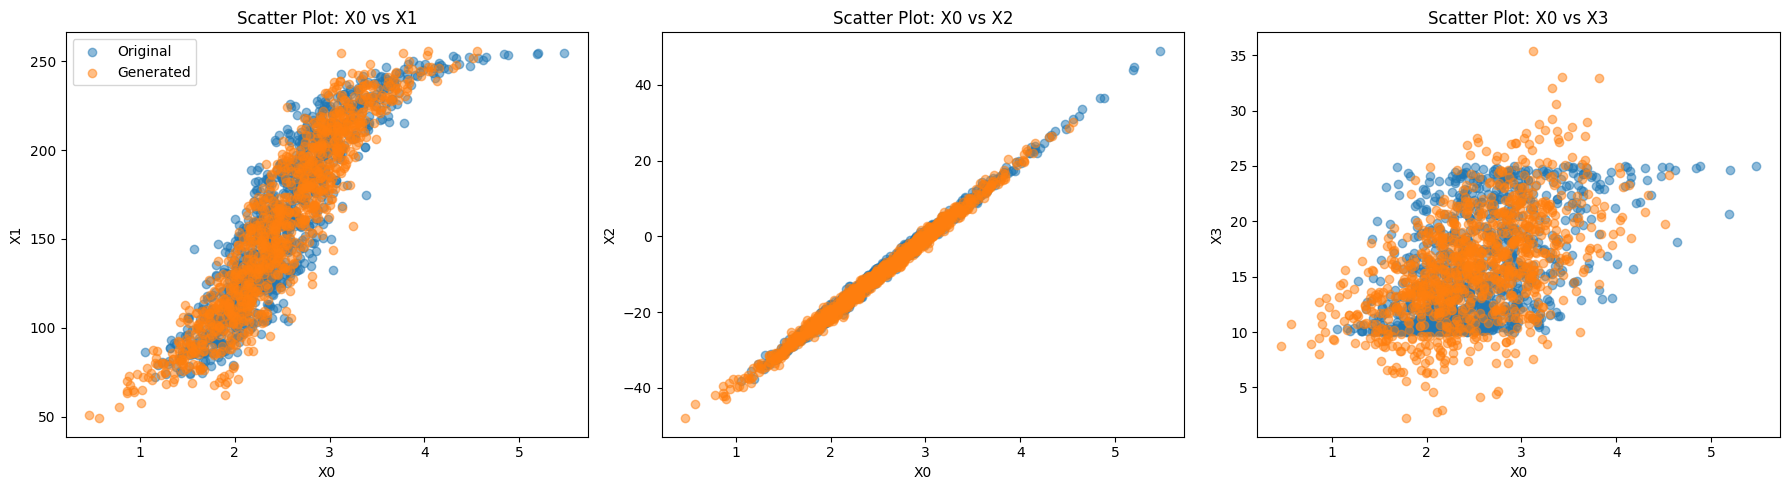

In [ ]:
# 生成性能の可視化

import matplotlib.pyplot as plt
import numpy as np
import torch

x_idx = 0
y_idxs = [1, 2, 3]

n = 1000
indices = np.random.choice(len(metrics), n)
X = metrics[indices]
xs = carefl.flow.sample(n)
X_gen = xs[-1].detach().cpu().numpy()

plt.figure(figsize=(18, 5))
for i, y_idx in enumerate(y_idxs):
    plt.subplot(1, 3, i+1)
    plt.scatter(X[:, x_idx], X[:, y_idx], alpha=0.5, label='Original')
    plt.scatter(X_gen[:, x_idx], X_gen[:, y_idx], alpha=0.5, label='Generated')
    plt.xlabel(f'X{x_idx}')
    plt.ylabel(f'X{y_idx}')
    plt.title(f'Scatter Plot: X{x_idx} vs X{y_idx}')
    if i == 0:
        plt.legend()
plt.tight_layout()
plt.show()

### 原因究明2:全体モデルによる反事実的画像のメタ情報を反因果予測器で予測してターゲットと比較

In [9]:
## UNetのロード
import torch
from diffusion.diffusion_model.models.model11 import UNet
from diffusion.utils.utils import load_checkpoint, load_json
import torch.optim  as optim


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
denoise_model = UNet().to(device)
optimizer = optim.Adam(denoise_model.parameters(), lr=1e-3)


# 実験設定ファイルパス
file_path = "/home/hashikami/results/2025-09-30_14/config_20250930.json"
config = load_json(file_path)
epochs = config['epochs']
scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[int(epochs * ratio) for ratio in [0.5, 0.8]],
    gamma=0.2
)


# checkpointの読み込み
checkpoint_path = "/home/hashikami/checkpoint/checkpoint_2025-09-30_15.pth"
denoise_model, optimizer, scheduler, start_epoch, loss = load_checkpoint(denoise_model, optimizer, scheduler, filename=checkpoint_path)
pipeline.denoise_model = denoise_model

In [45]:
from torch.utils.data import DataLoader
from dataset.morphomnist import MorphoMNISTLike
from typing import Dict, List


batch_size = 100
do_parent = 'intensity'
def evaluate_counterfactual(one_factual_batch, interventions: Dict[str, List[float]], predictors):

 
    testset = MorphoMNISTLike(root_dir="/home/hashikami/datadrive/morphomnist_all_model",
                                columns=['thickness', 'intensity', 'slant', 'width'], train=False)
    test_data_loader = DataLoader(testset, batch_size=batch_size, shuffle=True)
    one_factual_batch = next(iter(test_data_loader))


    QUARTILE_RANGES = {
        'thickness': [2.04805145, 2.881358275],
        'intensity': [117.097564, 197.4233375],
        'slant': [-19.0626455, -2.3332007],
        'width': [11.03513725, 19.5581495]
    }

    counterfactual_batch = pipeline.produce_counterfactuals(one_factual_batch, do_parent, interventions, w=0.1)
    counterfactual_result = evaluate_one_batch(counterfactual_batch, predictors)
    counterfactual_result = {atr: counterfactual_result[atr].item() for atr in counterfactual_result}
    print(counterfactual_result)
    

In [46]:
### 一様分布から介入値を生成させるパターン ###

interventions = {atr: np.random.uniform(QUARTILE_RANGES[atr][0], QUARTILE_RANGES[atr][1], size=one_factual_batch['image'].shape[0]).tolist() for atr in attribute_size.keys()}
evaluate_counterfactual(one_factual_batch, interventions, predictors)

sampling loop time step: 100%|██████████| 500/500 [00:16<00:00, 30.50it/s]

{'thickness': 0.7194014191627502, 'intensity': 43.296348571777344, 'slant': 14.610271453857422, 'width': 5.28631067276001}


In [47]:
### 訓練セットからランダムに選択した値を介入値とするパターン ###

intervention_source = MorphoMNISTLike(root_dir="/home/hashikami/datadrive/morphomnist_all_model",
                                columns=['thickness', 'intensity', 'slant', 'width'], train=True)
idxs = torch.randperm(len(intervention_source))[:batch_size] # select random indices from train set to perform interventions
interventions = {do_parent: torch.cat([intervention_source[id][do_parent].view(-1) for id in idxs]).tolist()}
evaluate_counterfactual(one_factual_batch, interventions, predictors)


sampling loop time step: 100%|██████████| 500/500 [00:16<00:00, 30.90it/s]

{'thickness': 0.7422223687171936, 'intensity': 58.82695007324219, 'slant': 14.655896186828613, 'width': 5.567441940307617}


## 1.3 調査3:そもそも条件付き拡散モデルの条件付き生成の性能はどのくらいなのか？

In [48]:
## UNetのロード
import torch
from diffusion.diffusion_model.models.model11 import UNet
from diffusion.utils.utils import load_checkpoint, load_json
import torch.optim  as optim


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
denoise_model = UNet().to(device)
optimizer = optim.Adam(denoise_model.parameters(), lr=1e-3)


# 実験設定ファイルパス
file_path = "/home/hashikami/results/2025-09-30_14/config_20250930.json"
config = load_json(file_path)
epochs = config['epochs']
scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[int(epochs * ratio) for ratio in [0.5, 0.8]],
    gamma=0.2
)


# checkpointの読み込み
checkpoint_path = "/home/hashikami/checkpoint/checkpoint_2025-09-30_15.pth"
denoise_model, optimizer, scheduler, start_epoch, loss = load_checkpoint(denoise_model, optimizer, scheduler, filename=checkpoint_path)

In [72]:
from diffusion.utils.diffusion_utils import DiffusionUtils

w = 0.1
image_size = 28
batch_size = 100

cond_source = MorphoMNISTLike(root_dir="/home/hashikami/datadrive/morphomnist_all_model",
                            columns=['thickness', 'intensity', 'slant', 'width'], train=True)
idxs = torch.randperm(len(cond_source))[:batch_size] # select random indices from train set to perform interventions
cond = torch.cat([torch.cat([cond_source[id][atr].view(-1) for id in idxs]).unsqueeze(1) for atr in attribute_size], dim=1).float().to("cuda")

utils = DiffusionUtils(timesteps=500)
imgs = utils.ddim_p_sample_loop(denoise_model, 0.0, 1, cond, w, image_size, batch_size, channels=1)

sampling loop time step: 100%|██████████| 500/500 [00:16<00:00, 30.02it/s]


In [73]:
### 生成後画像と属性の後処理 ###

from diffusion.utils.utils import scale_image_0_1_to_0_255

temp_images = scale_image_0_1_to_0_255(imgs[-1]) # 0~255スケール整数に変換
        
# 画像・メタ情報のスケールを全て[-1,1]に変換
temp_images = temp_images / 255.0 # [0, 255] -> [0, 1]
scaled_images = 2 * temp_images - 1 # [0, 1] -> [-1, 1]

# 条件値を全て[-1, 1]に変換
attrs = ['thickness', 'intensity', 'slant', 'width']
MIN_MAX = {
    "thickness": [0.82152224, 6.384839],
    "intensity": [66.48045, 254.93214],
    "slant": [-43.692436, 66.94711],
    "width": [10.000215, 24.999382],
    "image": [0.0, 255.0]
}
def normalize_meta(values):
    for k, v in MIN_MAX.items():
        if k == 'image':
            continue
        idx = attrs.index(k)
        values[:,idx] = (values[:,idx] - v[0]) / (v[1] - v[0])
        values[:,idx] = 2 * values[:,idx] - 1
        
    return values
        
scaled_cond = normalize_meta(cond)

generated_batch = {'image': scaled_images, **{attr: scaled_cond[:, attrs.index(attr)] for attr in attrs}}

In [74]:
cond_result = evaluate_one_batch(generated_batch, predictors)
cond_result = {key: cond_result[key].item() for key in cond_result}
print(cond_result)

{'thickness': 0.6119614243507385, 'intensity': 54.229087829589844, 'slant': 12.465285301208496, 'width': 5.301863193511963}
